In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [12]:
crosstab_result = pd.crosstab(df["category"],df["isBestSeller"])

In [13]:
crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [14]:
from scipy.stats import chi2_contingency

chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(36540.20270061387), np.float64(0.0))

In [15]:
from scipy.stats.contingency import association


association(crosstab_result, method="cramer")

0.1222829439760564

In [17]:
crosstab_prop = pd.crosstab(
    df["category"], df["isBestSeller"], normalize="index"
)

In [18]:
crosstab_prop

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811
...,...,...
Wind Instruments,0.972000,0.028000
Window Treatments,0.979079,0.020921
Women,0.988015,0.011985


In [19]:
top_10_categories = crosstab_prop.sort_values(
    by=True, ascending=False
).head(10)

top_10_categories

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
"Billiard, Snooker & Pool",0.967871,0.032129
Pet Supplies,0.969800,0.030200
Home Brewing & Wine Making,0.971545,0.028455
Wind Instruments,0.972000,0.028000


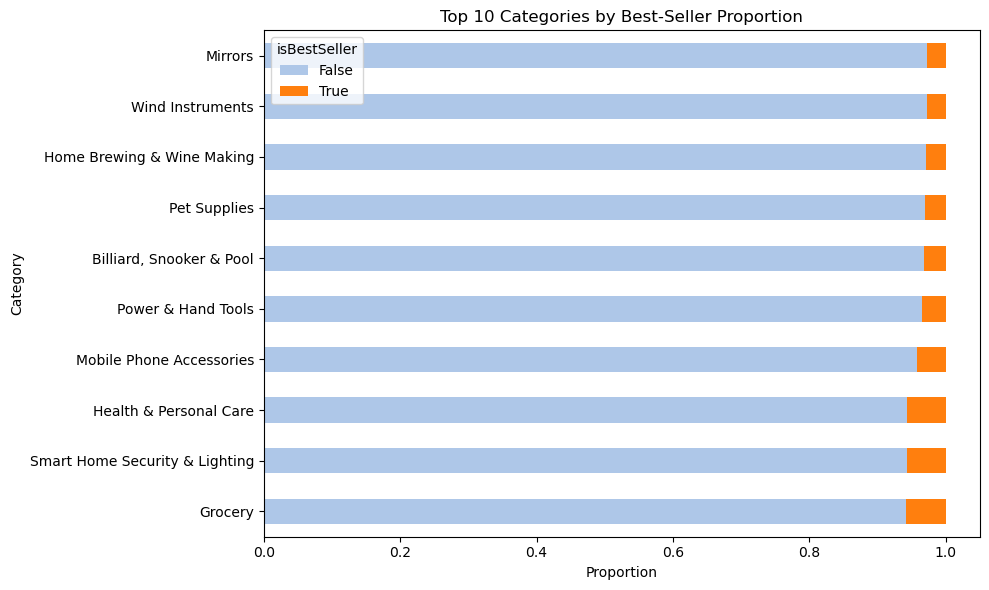

In [21]:
top_10_categories.plot(
    kind="barh", stacked=True, figsize=(10, 6), color=["#aec7e8", "#ff7f0e"]
)
plt.title("Top 10 Categories by Best-Seller Proportion")
plt.xlabel("Proportion")
plt.ylabel("Category")
plt.legend(title="isBestSeller", labels=["False", "True"])
plt.tight_layout()
plt.show()

In [22]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)


In [23]:
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr



In [24]:
df_filtered = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]


print(f"Original row count: {len(df)}")
print(f"Filtered row count (without price outliers): {len(df_filtered)}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

Original row count: 2443651
Filtered row count (without price outliers): 2115963
Lower bound: -44.01, Upper bound: 99.99


In [26]:
top20_cats = df_filtered["category"].value_counts().head(20).index
df_top20 = df_filtered[df_filtered["category"].isin(top20_cats)]

C:\Users\user\AppData\Local\Temp\ipykernel_4624\891775418.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")


<Axes: xlabel='category', ylabel='price'>

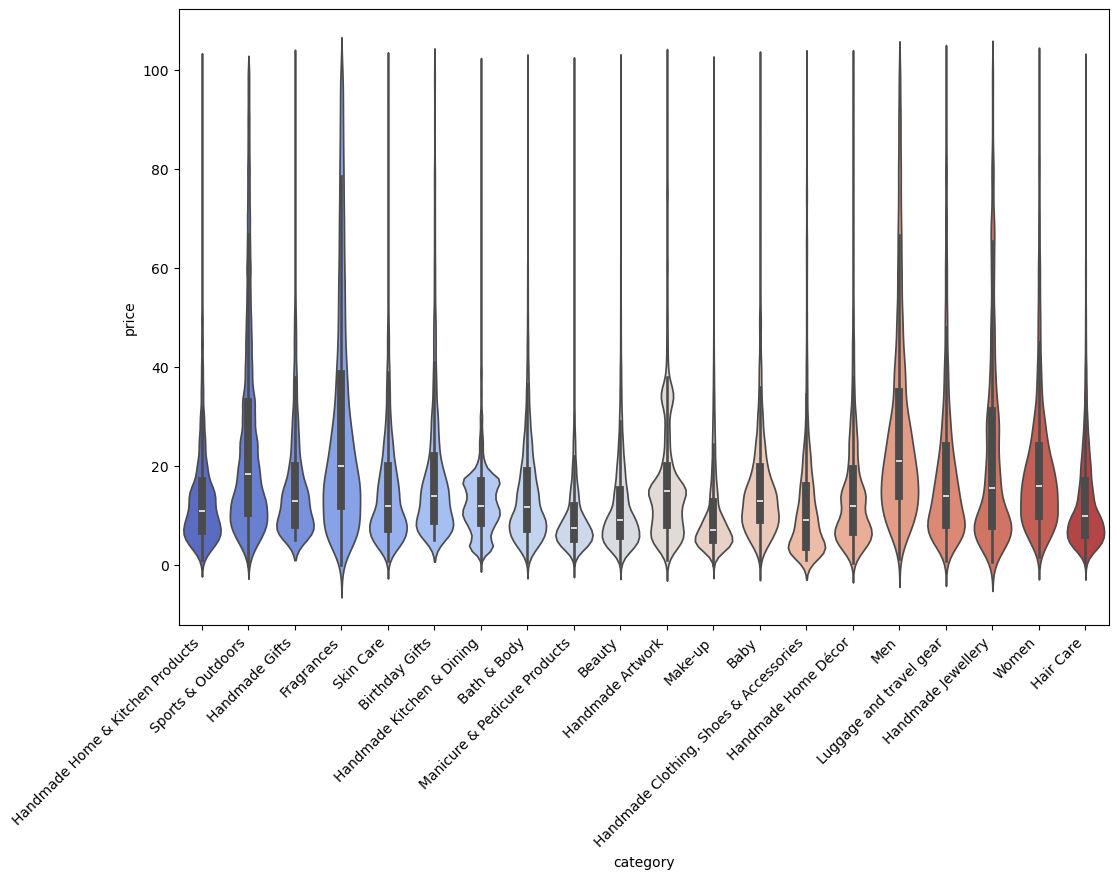

In [29]:
plt.figure(figsize=(12, 8))

plt.xticks(rotation=45, ha="right")

sns.violinplot(data=df_top20, x='category', y='price', palette="coolwarm")

In [36]:
top10_cats = df_filtered["category"].value_counts().head(10).index

In [37]:
df_top10_avg = (
    df_filtered[df_filtered["category"].isin(top10_cats)]
    .groupby("category", as_index=False)["price"]
    .mean()
    .sort_values(by="price", ascending=False)
)

C:\Users\user\AppData\Local\Temp\ipykernel_4624\636047826.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10_avg, x="category", y="price", palette="coolwarm")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Birthday Gifts'),
  Text(2, 0, 'Handmade Gifts'),
  Text(3, 0, 'Skin Care'),
  Text(4, 0, 'Bath & Body'),
  Text(5, 0, 'Hair Care'),
  Text(6, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(7, 0, 'Beauty'),
  Text(8, 0, 'Make-up'),
  Text(9, 0, 'Manicure & Pedicure Products')])

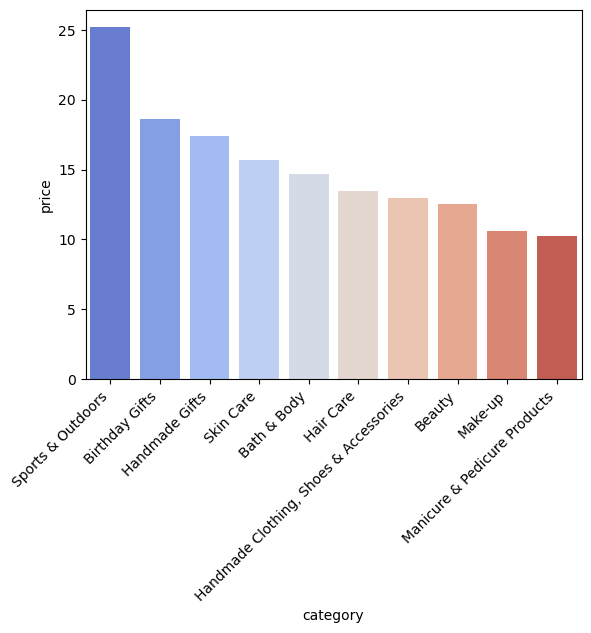

In [38]:
sns.barplot(data=df_top10_avg, x="category", y="price", palette="coolwarm")

plt.xticks(rotation=45, ha="right")

In [39]:
highest_avg_cat = df_filtered.groupby("category")["price"].mean().idxmax()
highest_avg_price = df_filtered.groupby("category")["price"].mean().max()

print(f"Category with highest average price: {highest_avg_cat}")
print(f"Highest Average Price: £{highest_avg_price:.2f}")

Category with highest average price: Motherboards
Highest Average Price: £68.77


In [40]:
df_top10 = df[df["category"].isin(top10_cats)]

C:\Users\user\AppData\Local\Temp\ipykernel_4624\1512558632.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x="category", y="stars", palette="coolwarm")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Sports & Outdoors'),
  Text(1, 0, 'Handmade Gifts'),
  Text(2, 0, 'Skin Care'),
  Text(3, 0, 'Birthday Gifts'),
  Text(4, 0, 'Bath & Body'),
  Text(5, 0, 'Manicure & Pedicure Products'),
  Text(6, 0, 'Beauty'),
  Text(7, 0, 'Make-up'),
  Text(8, 0, 'Handmade Clothing, Shoes & Accessories'),
  Text(9, 0, 'Hair Care')])

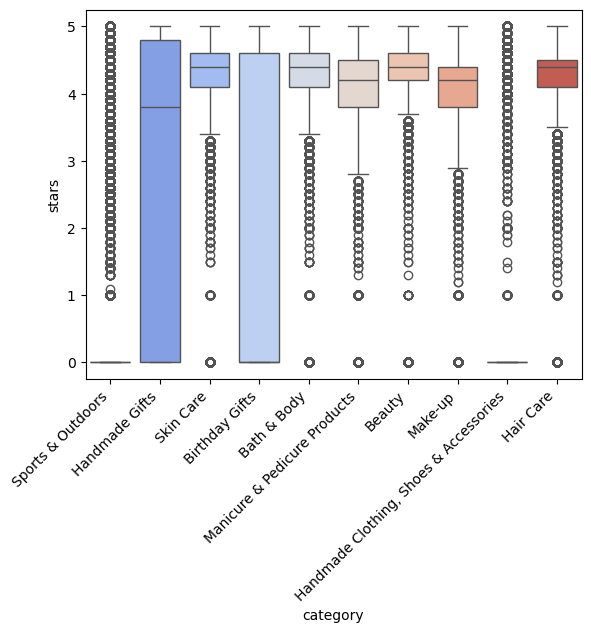

In [41]:
sns.boxplot(data=df_top10, x="category", y="stars", palette="coolwarm")

plt.xticks(rotation=45, ha="right")

In [42]:
highest_median_rating_cat = df.groupby("category")["stars"].median().idxmax()
highest_median_rating_val = df.groupby("category")["stars"].median().max()

print(f"Category with highest median rating: {highest_median_rating_cat}")
print(f"Highest Median Rating: {highest_median_rating_val:.2f}")

Category with highest median rating: Computer Memory
Highest Median Rating: 4.70


In [43]:
correlation = df["price"].corr(df['stars'])
correlation

np.float64(-0.1249067326214861)

In [44]:
correlation = df["price"].corr(df["stars"], method='spearman')
correlation

np.float64(-0.1331642546243379)

<Axes: xlabel='stars', ylabel='price'>

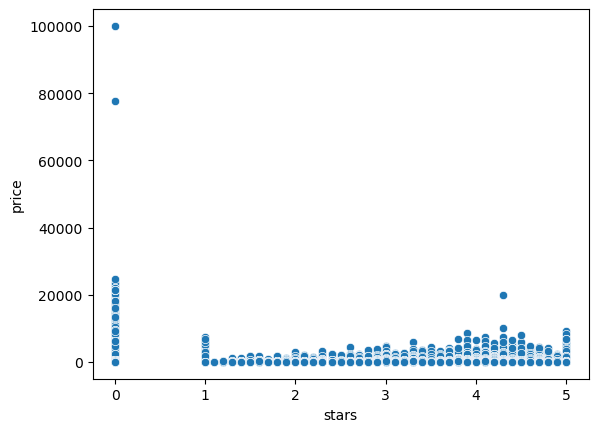

In [52]:
sns.scatterplot(data=df, x='stars', y='price')

<Axes: xlabel='stars', ylabel='price'>

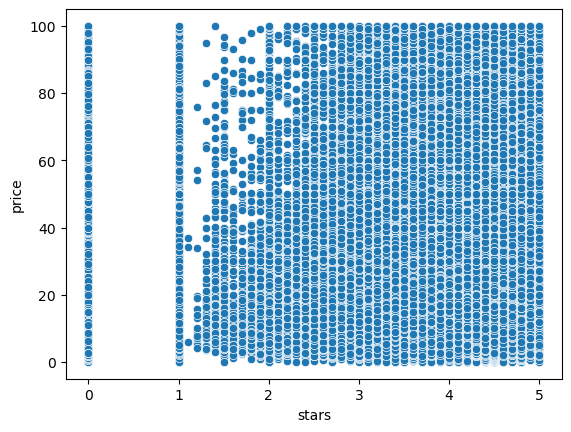

In [51]:
sns.scatterplot(data=df_filtered, x='stars', y='price')



In [55]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


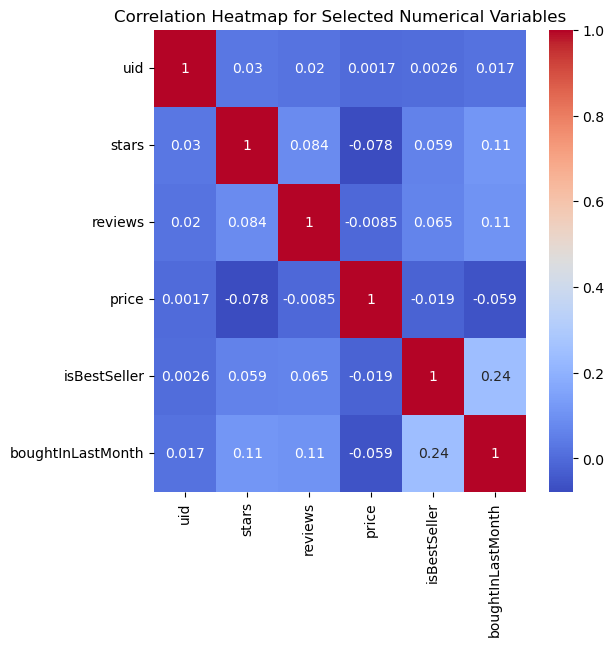

In [58]:
correlation_matrix = df_filtered.corr(numeric_only=True)

# Setting up the matplotlib figure with an appropriate size
plt.figure(figsize=(6, 6))

# Drawing the heatmap for the numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap for Selected Numerical Variables")
plt.show()

In [59]:
import statsmodels.api as sm

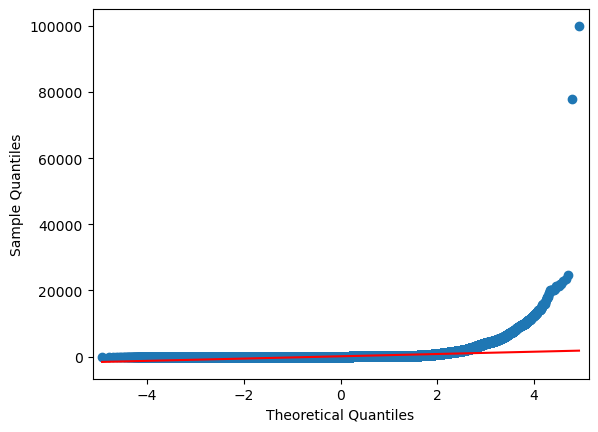

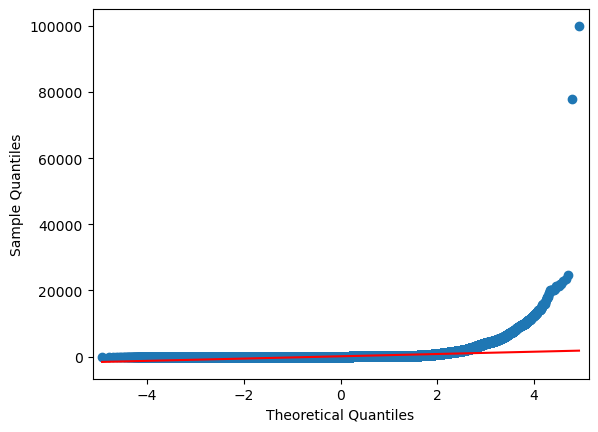

In [64]:

sm.qqplot(df["price"].dropna(), line="s")